# Treatment-response benchmark — Path2Space vs other methods

Compares the Path2Space pCR predictors against competing methods on the same
cohorts, for chemotherapy and trastuzumab (Shulman et al., *Cell* 2026).

Methods: **Path2Space (ST clusters)** and **Path2Space (combined)** (this repo,
notebooks `01`/`02`), **Imputed Bulk** (clusters from imputed bulk expression),
**Direct Model** (direct H&E predictor), **Sammut-ML**, and **ENLIGHT**.

Per-sample predictions for every method are shipped in
`../data/benchmark_predictions_{chemo,trastuzumab}.csv` (`y_test`, `y_pred_proba`,
`method`, `Cohort`). AUC and a stratified-bootstrap 95% CI are computed per
cohort and method.

## Setup

In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")

def auc_ci(y, p, n_boot=2000, seed=42):
    """AUC with a stratified-bootstrap 95% CI."""
    y, p = np.asarray(y), np.asarray(p)
    auc = roc_auc_score(y, p)
    rng = np.random.default_rng(seed)
    pos, neg = np.flatnonzero(y == 1), np.flatnonzero(y == 0)
    boot = []
    for _ in range(n_boot):
        idx = np.concatenate([rng.choice(pos, len(pos), replace=True),
                              rng.choice(neg, len(neg), replace=True)])
        if len(np.unique(y[idx])) == 2:
            boot.append(roc_auc_score(y[idx], p[idx]))
    return auc, np.percentile(boot, 2.5), np.percentile(boot, 97.5)

METHOD_NAME = {"spatial": "Path2Space\n(ST clusters)",
               "Path2Space (combined)": "Path2Space\n(combined)",
               "Imputed Bulk": "Imputed Bulk", "Direct Model": "Direct Model",
               "Sammut-ML": "Sammut-ML", "ENLIGHT": "ENLIGHT"}
COHORT_NAME = {"TransNEO (Cross-validation)": "TransNEO (CV)",
               "IMPRESS (External validation set)": "IMPRESS",
               "PBCP\n(External validation)": "PBCP",
               "PBCP\n(External validation set)": "PBCP"}
COHORT_ORDER = ["TransNEO (CV)", "IMPRESS", "PBCP"]
COLORS = {"Path2Space\n(ST clusters)": "#7570b3", "Path2Space\n(combined)": "#b3a2c7",
          "Imputed Bulk": "#bdbdbd", "Direct Model": "#969696",
          "Sammut-ML": "#e6ab02", "ENLIGHT": "#66a61e"}

## Load per-sample predictions

In [2]:
def load(treatment):
    d = pd.read_csv(f"../data/benchmark_predictions_{treatment}.csv", index_col=0)
    d["method"] = d["method"].map(METHOD_NAME)
    d["Cohort"] = d["Cohort"].map(COHORT_NAME)
    return d.dropna(subset=["y_test", "y_pred_proba", "method"])

pred = {"chemo": load("chemo"), "trastuzumab": load("trastuzumab")}
for t, d in pred.items():
    print(t, "-", d.shape[0], "rows,", sorted(d["method"].str.replace(chr(10)," ").unique()))

chemo - 620 rows, ['Direct Model', 'Imputed Bulk', 'Path2Space (ST clusters)', 'Sammut-ML']
trastuzumab - 659 rows, ['Direct Model', 'ENLIGHT', 'Imputed Bulk', 'Path2Space (ST clusters)', 'Path2Space (combined)', 'Sammut-ML']


## AUC and bootstrap CI per cohort and method

In [3]:
rows = []
for treatment, d in pred.items():
    for (cohort, method), g in d.groupby(["Cohort", "method"]):
        if len(np.unique(g["y_test"])) < 2:
            continue
        auc, lo, hi = auc_ci(g["y_test"], g["y_pred_proba"])
        rows.append({"treatment": treatment, "cohort": cohort, "method": method,
                     "n": len(g), "AUC": auc, "lo": lo, "hi": hi})
results = pd.DataFrame(rows)
results.round(3)

,treatment,cohort,method,n,AUC,lo,hi
0,chemo,IMPRESS,Direct Model,64,0.575,0.432,0.716
1,chemo,IMPRESS,Imputed Bulk,64,0.517,0.370,0.658
2,chemo,IMPRESS,Path2Space\n(ST clusters),64,0.741,0.614,0.852
3,chemo,PBCP,Direct Model,19,0.700,0.328,1.000
4,chemo,PBCP,Imputed Bulk,19,0.814,0.571,1.000
5,chemo,PBCP,Path2Space\n(ST clusters),19,0.886,0.714,1.000
6,chemo,TransNEO (CV),Direct Model,93,0.695,0.569,0.814
7,chemo,TransNEO (CV),Imputed Bulk,94,0.735,0.611,0.849
8,chemo,TransNEO (CV),Path2Space\n(ST clusters),93,0.753,0.647,0.845
9,chemo,TransNEO (CV),Sammut-ML,91,0.898,0.831,0.956


## Chemotherapy benchmark

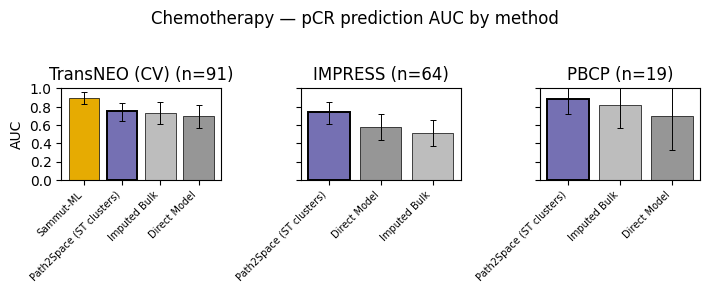

In [4]:
d = results[results["treatment"] == "chemo"]
cohorts = [c for c in COHORT_ORDER if c in d["cohort"].values]
fig, axes = plt.subplots(1, len(cohorts), figsize=(2.4 * len(cohorts), 2.8), sharey=True)
for ax, cohort in zip(np.atleast_1d(axes), cohorts):
    g = d[d["cohort"] == cohort].sort_values("AUC", ascending=False)
    x = np.arange(len(g))
    yerr = np.vstack([g["AUC"] - g["lo"], g["hi"] - g["AUC"]])
    bars = ax.bar(x, g["AUC"], color=[COLORS[m] for m in g["method"]],
                  edgecolor="black", linewidth=0.5,
                  yerr=yerr, error_kw=dict(elinewidth=0.7, capsize=2, capthick=0.7))
    for bar, m in zip(bars, g["method"]):
        if m.startswith("Path2Space"):
            bar.set_linewidth(1.4)
    n = g["n"].iloc[0]
    ax.set(ylim=(0, 1.0), title=f"{cohort} (n={n})", xticks=x)
    ax.set_xticklabels([m.replace(chr(10), " ") for m in g["method"]],
                       rotation=45, ha="right", fontsize=7)
    ax.set_yticks(np.arange(0, 1.01, 0.2))
    if ax is np.atleast_1d(axes)[0]:
        ax.set_ylabel("AUC")
fig.suptitle("Chemotherapy — pCR prediction AUC by method", y=1.03)
fig.tight_layout()
plt.show()

## Trastuzumab benchmark

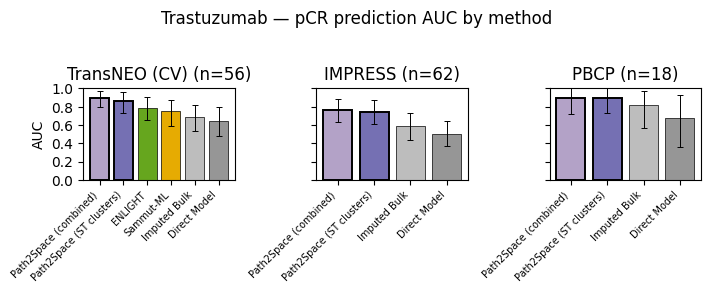

In [5]:
d = results[results["treatment"] == "trastuzumab"]
cohorts = [c for c in COHORT_ORDER if c in d["cohort"].values]
fig, axes = plt.subplots(1, len(cohorts), figsize=(2.4 * len(cohorts), 2.8), sharey=True)
for ax, cohort in zip(np.atleast_1d(axes), cohorts):
    g = d[d["cohort"] == cohort].sort_values("AUC", ascending=False)
    x = np.arange(len(g))
    yerr = np.vstack([g["AUC"] - g["lo"], g["hi"] - g["AUC"]])
    bars = ax.bar(x, g["AUC"], color=[COLORS[m] for m in g["method"]],
                  edgecolor="black", linewidth=0.5,
                  yerr=yerr, error_kw=dict(elinewidth=0.7, capsize=2, capthick=0.7))
    for bar, m in zip(bars, g["method"]):
        if m.startswith("Path2Space"):
            bar.set_linewidth(1.4)
    n = g["n"].iloc[0]
    ax.set(ylim=(0, 1.0), title=f"{cohort} (n={n})", xticks=x)
    ax.set_xticklabels([m.replace(chr(10), " ") for m in g["method"]],
                       rotation=45, ha="right", fontsize=7)
    ax.set_yticks(np.arange(0, 1.01, 0.2))
    if ax is np.atleast_1d(axes)[0]:
        ax.set_ylabel("AUC")
fig.suptitle("Trastuzumab — pCR prediction AUC by method", y=1.03)
fig.tight_layout()
plt.show()

## Summary

In [6]:
summary = (results.assign(method=lambda x: x["method"].str.replace(chr(10), " "))
           .pivot_table(index=["treatment", "cohort"], columns="method", values="AUC"))
summary.round(3)

method                     Direct Model  ENLIGHT  Imputed Bulk  \
treatment   cohort                                               
chemo       IMPRESS               0.575      NaN         0.517   
            PBCP                  0.700      NaN         0.814   
            TransNEO (CV)         0.695      NaN         0.735   
trastuzumab IMPRESS               0.503      NaN         0.584   
            PBCP                  0.675      NaN         0.818   
            TransNEO (CV)         0.647    0.784         0.686   

method                     Path2Space (ST clusters)  Path2Space (combined)  \
treatment   cohort                                                           
chemo       IMPRESS                           0.741                    NaN   
            PBCP                              0.886                    NaN   
            TransNEO (CV)                     0.753                    NaN   
trastuzumab IMPRESS                           0.743                  0.765   
            PBCP                              0.896                  0.896   
            TransNEO (CV)                     0.858                  0.894   

method                     Sammut-ML  
treatment   cohort                    
chemo       IMPRESS              NaN  
            PBCP                 NaN  
            TransNEO (CV)      0.898  
trastuzumab IMPRESS              NaN  
            PBCP                 NaN  
            TransNEO (CV)      0.748